
Performance Comparison

 Array Size  Binary Time (s)  Binary Comparisons  Interpolation Time (s)  Interpolation Comparisons
       1000         0.000012                   9                0.000006                          2
       5000         0.000005                  12                0.000003                          2
      10000         0.000004                  13                0.000002                          2
      50000         0.000016                  15                0.000007                          2
     100000         0.000011                  16                0.000005                          2


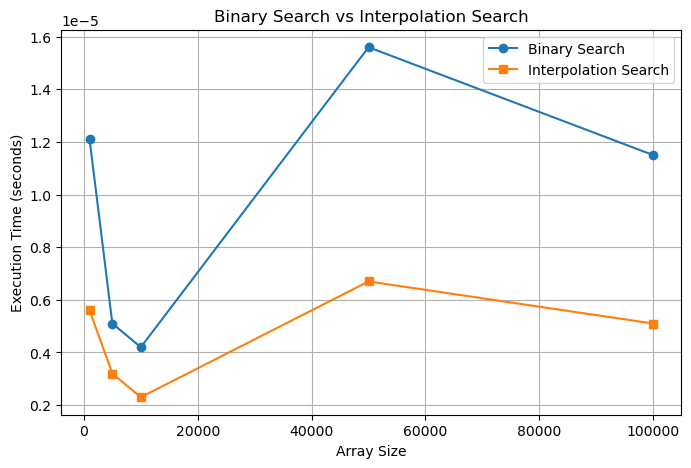

In [3]:
import time
import random
import pandas as pd
import matplotlib.pyplot as plt


def binary_search(arr, key):
    low = 0
    high = len(arr) - 1
    comparisons = 0

    while low <= high:
        mid = (low + high) // 2
        comparisons += 1

        if arr[mid] == key:
            return mid, comparisons
        elif arr[mid] < key:
            low = mid + 1
        else:
            high = mid - 1

    return -1, comparisons



def interpolation_search(arr, key):
    low = 0
    high = len(arr) - 1
    comparisons = 0

    while (low <= high and
           key >= arr[low] and
           key <= arr[high]):

        comparisons += 1

        if low == high:
            if arr[low] == key:
                return low, comparisons
            return -1, comparisons

        pos = low + int(
            ((high - low) / (arr[high] - arr[low]))
            * (key - arr[low])
        )

        comparisons += 1

        if arr[pos] == key:
            return pos, comparisons

        elif arr[pos] < key:
            low = pos + 1

        else:
            high = pos - 1

    return -1, comparisons



sizes = [1000, 5000, 10000, 50000, 100000]

results = []

for n in sizes:

    
    arr = list(range(n))

    
    key = arr[n // 2]

    
    start = time.perf_counter()
    _, b_comp = binary_search(arr, key)
    binary_time = time.perf_counter() - start

    
    start = time.perf_counter()
    _, i_comp = interpolation_search(arr, key)
    interp_time = time.perf_counter() - start

    results.append([
        n,
        binary_time,
        b_comp,
        interp_time,
        i_comp
    ])


df = pd.DataFrame(results,
                  columns=[
                      "Array Size",
                      "Binary Time (s)",
                      "Binary Comparisons",
                      "Interpolation Time (s)",
                      "Interpolation Comparisons"
                  ])

print("\nPerformance Comparison\n")
print(df.to_string(index=False))


plt.figure(figsize=(8, 5))

plt.plot(df["Array Size"],
         df["Binary Time (s)"],
         marker='o',
         label="Binary Search")

plt.plot(df["Array Size"],
         df["Interpolation Time (s)"],
         marker='s',
         label="Interpolation Search")

plt.xlabel("Array Size")
plt.ylabel("Execution Time (seconds)")
plt.title("Binary Search vs Interpolation Search")
plt.legend()
plt.grid(True)

plt.show()